In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import random
from google.cloud import bigquery

client = bigquery.Client(project="ocean-breeze-tier-1")

C:\Users\sophie.wilson\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## This is a test implimentation of leiden graph so i can see how it works

In [3]:
edges = [
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),
    (4, 5),
    (5, 0),
    (6, 7),
    (7, 8),
    (8, 9),
    (9, 6),
    (3, 9),
    (5, 6),
    (10, 11),
    (11, 12),
    (12, 13),
    (13, 14),
    (14, 10),
    (1, 11),
    # added to reach 50 pairs
    (15, 16),
    (16, 17),
    (17, 18),
    (18, 19),
    (19, 20),
    (20, 15),
    (21, 22),
    (22, 23),
    (23, 24),
    (24, 25),
    (25, 26),
    (26, 27),
    (27, 28),
    (28, 29),
    (29, 21),
    (14, 15),
    (20, 21),
    (18, 23),
    (12, 17),
    (8, 22),
    (0, 10),
    (25, 30),
    (30, 31),
    (31, 32),
    (32, 33),
    (33, 34),
    (34, 35),
    (35, 36),
    (36, 37),
    (37, 38),
    (38, 39),
    (39, 30),
]

In [26]:
# query = """
# WITH top_level1_fos AS (
#   SELECT
#     pf.PublicationId,
#     pf.FieldOfStudyId,
#     fs.DisplayName AS FieldOfStudyName,
#     fs.Level,
#     pf.Similarity
#   FROM `airak.PublicationFieldOfStudy` pf
#   JOIN `airak.FieldOfStudy` fs
#     ON pf.FieldOfStudyId = fs.FieldOfStudyId
#   WHERE fs.Level = 3
#   QUALIFY
#     ROW_NUMBER() OVER (
#       PARTITION BY pf.PublicationId
#       ORDER BY pf.Similarity DESC, pf.FieldOfStudyId
#     ) = 1
# )

# SELECT
#   pc.PublicationId,
#   pc.CitedPublicationId
#   -- t.FieldOfStudyId,
#   -- t.FieldOfStudyName,
#   -- t.Similarity
# FROM `ocean-breeze-tier-1.airak.PublicationCitation` pc
# JOIN `airak.Publication` p
#   ON pc.PublicationId = p.PublicationId
# JOIN top_level1_fos t
#   ON pc.PublicationId = t.PublicationId
# WHERE p.PublishedYear = 2025
# --AND t.FieldOfStudyId = 8735168
# ORDER BY pc.PublicationId


# """

query = """

SELECT
  pc.PublicationId,
  pc.CitedPublicationId,
  p.Title
  -- t.FieldOfStudyId,
  -- t.FieldOfStudyName,
  -- t.Similarity
FROM `ocean-breeze-tier-1.airak.PublicationCitation` pc
JOIN `airak.Publication` p
  ON pc.PublicationId = p.PublicationId

WHERE p.PublishedYear = 2025
AND p.JournalId IN (2336462209025, 1589137899520)
--AND t.FieldOfStudyId = 8735168
ORDER BY pc.PublicationId
"""

query = query_job = client.query(query)
results = query_job.result()

df = results.to_dataframe()

c:\Users\sophie.wilson\AppData\Local\miniconda3\envs\scope_drift\lib\site-packages\google\cloud\bigquery\table.py:1965: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [27]:
edges = list(zip(df["PublicationId"], df["CitedPublicationId"]))
# or: edges = df[["PublicationId", "CitedPublicationId"]].itertuples(index=False, name=None)

print(edges[:10])

[(957889382828978, 1151051823561), (957889382828978, 497254140281871), (957889382828978, 781684461548), (957889382828978, 50809469600622), (957889382828978, 1692217554470), (957889382828978, 670015394870), (957889382828978, 1709399209153), (957889382828978, 1116691678910), (957889382828978, 1623498187237), (957889382828978, 1760942144906)]


In [ ]:
# Create the graph and add the edges
graph = nx.Graph()
graph.add_edges_from(edges)

# Improve the visualization with a layout and better styling
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(graph, seed=42)  # Use a seed for consistent layout

# Draw the graph with additional details
nx.draw_networkx(
    graph,
    pos,
    with_labels=False,
    # node_color="lightblue",
    node_size=50,
    # font_size=1,
    # font_color="black",
    # edge_color="gray",
)

# # Show the graph
plt.title("Graph Visualization", fontsize=14)
plt.show()


1. Initialization: Start with each node in its own community.
2. Local Movement Phase: Move nodes to neighboring communities to maximize modularity.
3. Aggregation Phase: Merge nodes within the same community and repeat the process.

C:\Users\sophie.wilson\AppData\Local\Temp\ipykernel_13408\2082738952.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap("viridis", len(unique_communities)),


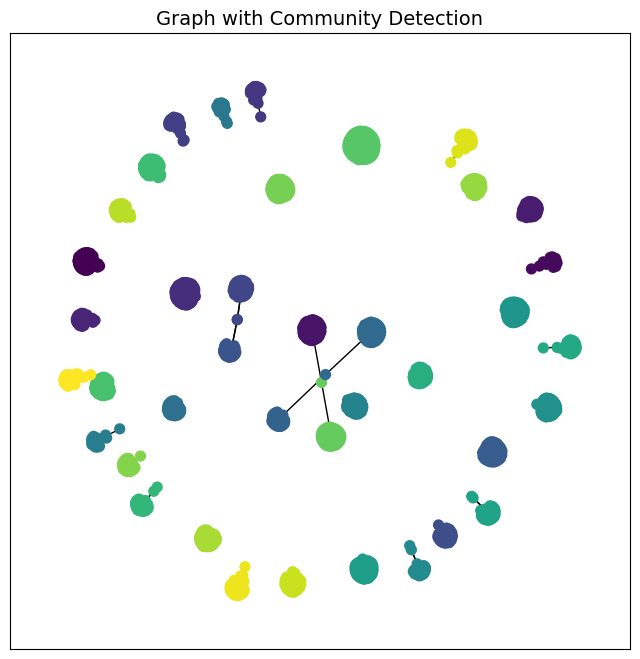

In [ ]:
# Step 1: Initialize each node in its own community
communities = {node: node for node in graph.nodes()}


# Step 2: Define a function to calculate modularity gain
def modularity_gain(graph, communities, node, target_community):
    internal_edges = sum(
        1
        for neighbor in graph.neighbors(node)
        if communities[neighbor] == target_community
    )
    return internal_edges


# Step 3: Iteratively move nodes to maximize modularity
for _ in range(500):  # Arbitrary number of iterations
    nodes = list(graph.nodes())
    random.shuffle(nodes)
    for node in nodes:
        best_community = communities[node]
        max_gain = 0
        for neighbor in graph.neighbors(node):
            target_community = communities[neighbor]
            gain = modularity_gain(graph, communities, node, target_community)
            if gain > max_gain:
                best_community = target_community
                max_gain = gain
        communities[node] = best_community


# Assign colors based on the community each node belongs to
unique_communities = list(set(communities.values()))
color_map = {community: i for i, community in enumerate(unique_communities)}
node_colors = [color_map[communities[node]] for node in graph.nodes()]

# Draw the graph with communities highlighted
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(graph, seed=42)
nx.draw_networkx(
    graph,
    pos,
    with_labels=False,
    arrows=True,
    node_color=node_colors,
    node_size=50,
    cmap=plt.cm.get_cmap("viridis", len(unique_communities)),
)

# Title and display the graph
plt.title("Graph with Community Detection", fontsize=14)
plt.show()

Next, we merge nodes in the same community and rebuild the graph with fewer nodes.

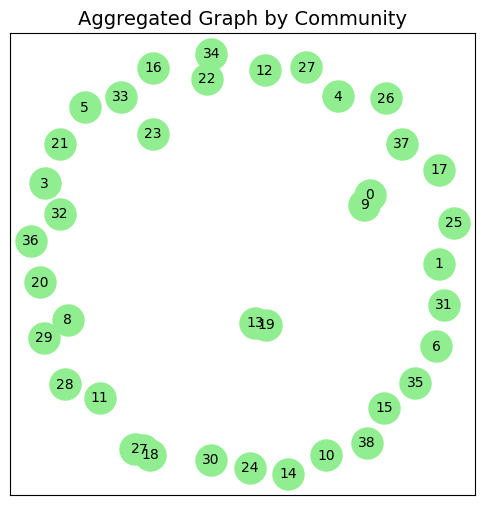

In [ ]:
# Create a new graph where each community is represented as a single node
aggregated_graph = nx.Graph()
community_map = {}

# Create a mapping from community to a unique node in the aggregated graph
for node, community in communities.items():
    if community not in community_map:
        community_map[community] = len(community_map)
        aggregated_graph.add_node(community_map[community])

# Add edges between communities if they are connected in the original graph
for edge in graph.edges():
    node1, node2 = edge
    community1 = community_map[communities[node1]]
    community2 = community_map[communities[node2]]
    if community1 != community2:
        aggregated_graph.add_edge(community1, community2)

# Visualize the aggregated graph
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(aggregated_graph, seed=42)
nx.draw_networkx(
    aggregated_graph,
    pos,
    with_labels=True,
    node_color="lightgreen",
    node_size=500,
    font_size=10,
    font_color="black",
    edge_color="gray",
)

plt.title("Aggregated Graph by Community", fontsize=14)
plt.show()

Now testing on real data